In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sales = pd.read_csv("Pizza_Sale - pizza_sales.csv")

In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48604 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48613 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48597 non-null  object 
 10  pizza_ingredients  48607 non-null  object 
 11  pizza_name         48613 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [5]:
df_sales.dropna(inplace= True)

In [6]:
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'], format='mixed', dayfirst=True)

In [11]:
df_sales[df_sales['order_date']=="2015-01-01"]["quantity"].sum()

np.int64(156)

In [7]:
daily_sales = df_sales.groupby('order_date')['quantity'].sum()

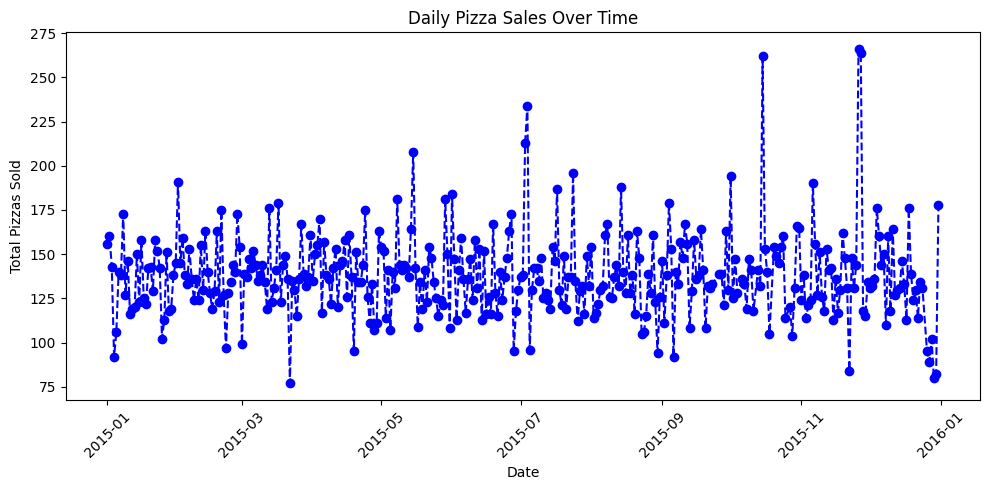

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, color='blue', marker='o', linestyle='dashed')
plt.title('Daily Pizza Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Pizzas Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
category_sales = df_sales.groupby('pizza_category')['quantity'].sum()
     

C:\Users\rahul\AppData\Local\Temp\ipykernel_29920\1282521964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="muted")


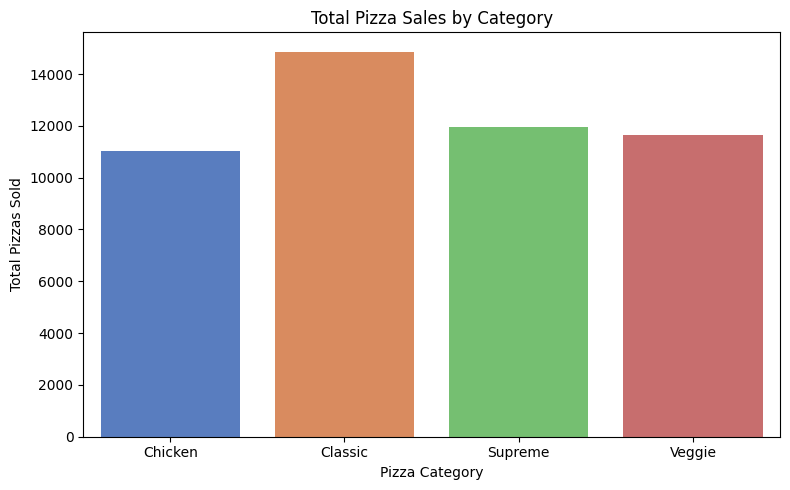

In [14]:

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="muted")
plt.title('Total Pizza Sales by Category')
plt.xlabel('Pizza Category')
plt.ylabel('Total Pizzas Sold')
plt.tight_layout()
plt.show()

In [15]:
monthly_sales = df_sales.groupby(df_sales['order_date'].dt.to_period('M'))['quantity'].sum()

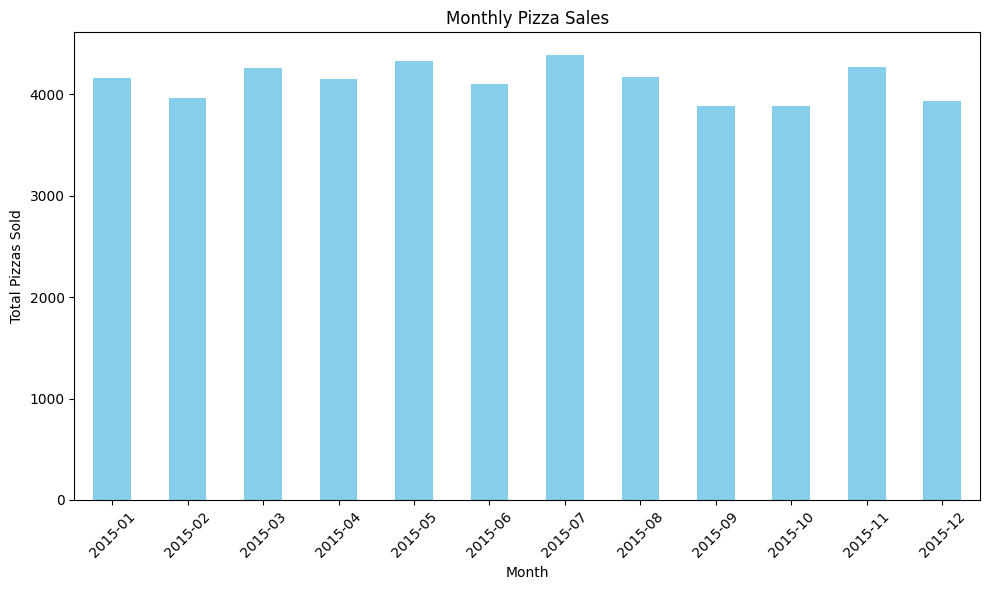

In [16]:
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Monthly Pizza Sales')
plt.xlabel('Month')
plt.ylabel('Total Pizzas Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
size_sales = df_sales.groupby('pizza_size')['quantity'].sum()

In [19]:
size_sales

pizza_size
L      18926
M      15616
S      14386
XL       552
XXL       28
Name: quantity, dtype: int64

Text(0.5, 1.0, 'Monthly Pizza Size Sales')

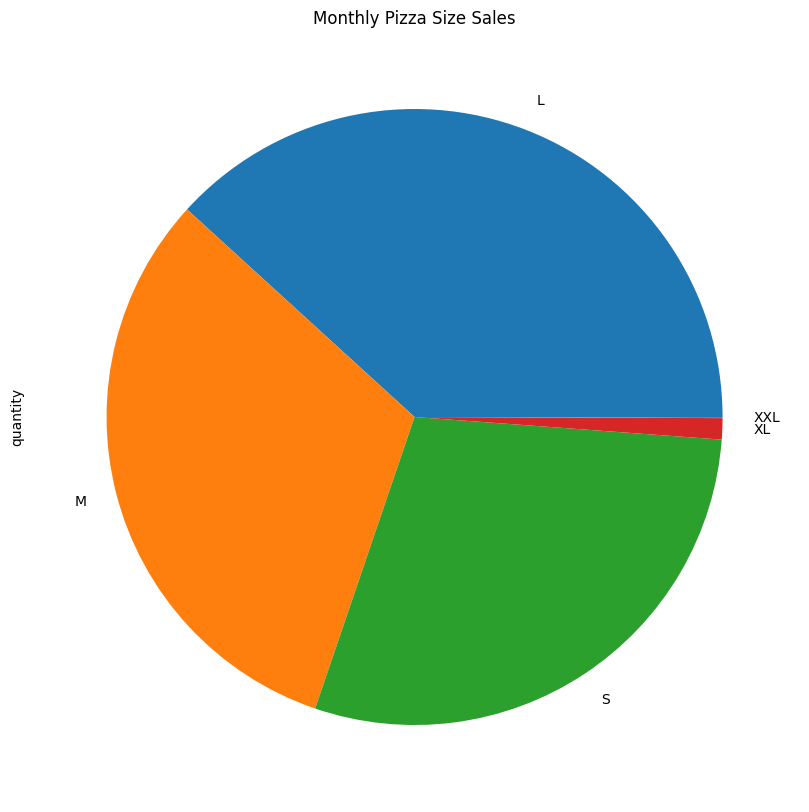

In [23]:
size_sales.plot.pie(figsize=(10,10))
plt.title('Monthly Pizza Size Sales')